# Part 1: Install Required Libraries

This section installs all Python libraries required for:
- Data processing
- NLP preprocessing
- Machine learning model development
- Data visualization
- Model saving

In [39]:
!pip install pandas numpy matplotlib seaborn nltk scikit-learn gensim wordcloud joblib streamlit

# Part 2: Import Required Libraries

The libraries imported are used for:
- Dataset handling
- Text preprocessing
- Feature extraction
- Model training
- Model evaluation
- Visualization

In [40]:
import pandas as pd
import numpy as np

import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer


import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud


from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer


from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


import joblib

# Part 3: Download NLP Resources

Download required NLTK packages:
- Tokenizer
- Stopwords
- WordNet for lemmatization


In [41]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# Part 4: Load Dataset

The BBC News dataset contains:
- 2,225 news articles
- 5 different categories:
    - Business
    - Entertainment
    - Politics
    - Sport
    - Technology

Dataset columns:
- text: News article content
- category: News category label

In [42]:
df = pd.read_csv(
    "/content/bbc-text.csv"
)

df.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


# Part 5: Dataset Exploration

This section analyzes:
- Dataset size
- Data types
- Missing values
- Category distribution

In [43]:
df.shape

(2225, 2)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  2225 non-null   object
 1   text      2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB


In [45]:
df.isnull().sum()

,0
category,0
text,0


Remove missing values (if any):

In [46]:
df.dropna(inplace=True)

# Part 6: Category Distribution Visualization

This visualization shows the number of articles
available in each news category.

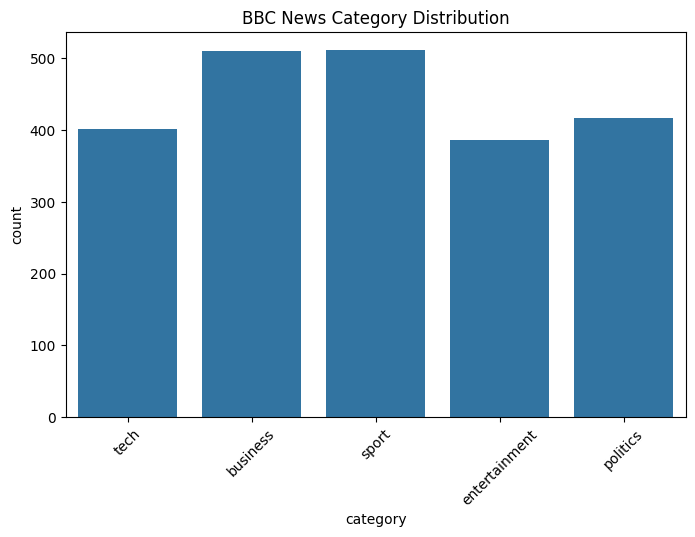

In [47]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='category'
)

plt.title(
    "BBC News Category Distribution"
)

plt.xticks(rotation=45)

plt.show()

# Part 7: Text Preprocessing

The preprocessing pipeline includes:

1. Convert text to lowercase
2. Remove URLs
3. Remove special characters
4. Tokenization
5. Stopword removal
6. Lemmatization

In [48]:
stop_words = set(
    stopwords.words('english')
)


lemmatizer = WordNetLemmatizer()



def preprocess_text(text):

    text = text.lower()


    text = re.sub(
        r"http\S+",
        "",
        text
    )


    text = re.sub(
        r"[^a-zA-Z]",
        " ",
        text
    )


    tokens = word_tokenize(text)



    tokens = [
        word
        for word in tokens
        if word not in stop_words
    ]


    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]


    return " ".join(tokens)

# Part 8: Apply Text Preprocessing

The preprocessing function is applied
to all news articles.

In [49]:
import nltk
nltk.download('punkt_tab') # Download the missing 'punkt_tab' resource

df['clean_text'] = df['text'].apply(
    preprocess_text
)

df[['text','clean_text']].head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,text,clean_text
0,tv future in the hands of viewers with home th...,tv future hand viewer home theatre system plas...
1,worldcom boss left books alone former worldc...,worldcom bos left book alone former worldcom b...
2,tigers wary of farrell gamble leicester say ...,tiger wary farrell gamble leicester say rushed...
3,yeading face newcastle in fa cup premiership s...,yeading face newcastle fa cup premiership side...
4,ocean s twelve raids box office ocean s twelve...,ocean twelve raid box office ocean twelve crim...


# Part 9: Word Cloud Visualization

Word clouds display the most frequently
appearing words in each news category.

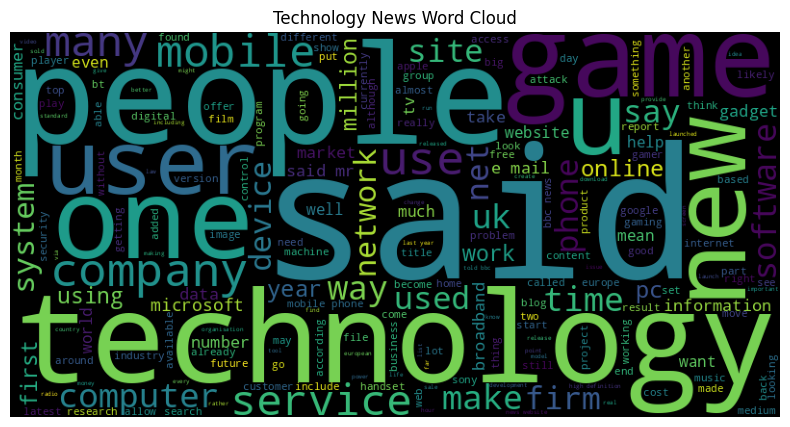

In [50]:
technology_text = " ".join(
    df[
        df.category=="tech"
    ]['clean_text']
)


wordcloud = WordCloud(
    width=800,
    height=400
).generate(
    technology_text
)


plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title(
    "Technology News Word Cloud"
)

plt.show()

# Part 10: Train-Test Split

The dataset is divided into:
- 80% training data
- 20% testing data

Training data is used to train models.
Testing data evaluates model performance.

In [51]:
X = df['clean_text']

y = df['category']


X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

# Part 11: TF-IDF + N-gram Feature Extraction

TF-IDF is combined with N-gram features to capture
both individual words and word combinations.

The model uses:

- Unigram (single words)
- Bigram (two consecutive words)
- Trigram (three consecutive words)

Example:

Sentence:
"new technology development"

Generated features:

Unigram:
- new
- technology
- development

Bigram:
- new technology
- technology development

Trigram:
- new technology development

This allows the classifier to understand more
meaningful phrases from news articles.

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer


# TF-IDF with N-gram features

tfidf_ngram = TfidfVectorizer(

    max_features=10000,

    ngram_range=(1,3),

    min_df=2,

    max_df=0.95

)


# Fit training data

X_train_tfidf = tfidf_ngram.fit_transform(
    X_train
)


# Transform testing data

X_test_tfidf = tfidf_ngram.transform(
    X_test
)


print(
    "Training Feature Shape:",
    X_train_tfidf.shape
)


print(
    "Testing Feature Shape:",
    X_test_tfidf.shape
)

Training Feature Shape: (1780, 10000)
Testing Feature Shape: (445, 10000)


# Part 12: Naive Bayes Classification Model

Naive Bayes is selected as a baseline model
because it performs well on text classification tasks.

In [53]:
nb_model = MultinomialNB()


nb_model.fit(
    X_train_tfidf,
    y_train
)


nb_prediction = nb_model.predict(
    X_test_tfidf
)

# Part 13: Support Vector Machine (SVM) Model

SVM is used because it performs effectively
on high-dimensional text data.

In [54]:
svm_model = LinearSVC()


svm_model.fit(
    X_train_tfidf,
    y_train
)


svm_prediction = svm_model.predict(
    X_test_tfidf
)

# Part 14: Model Evaluation

Evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-score

These metrics compare the performance
of different machine learning models.

In [55]:
def evaluate_model(y_true,y_pred,name):

    print(name)

    print(
        "Accuracy:",
        accuracy_score(y_true,y_pred)
    )


    print(
        "Precision:",
        precision_score(
            y_true,
            y_pred,
            average='weighted'
        )
    )


    print(
        "Recall:",
        recall_score(
            y_true,
            y_pred,
            average='weighted'
        )
    )


    print(
        "F1 Score:",
        f1_score(
            y_true,
            y_pred,
            average='weighted'
        )
    )


evaluate_model(
    y_test,
    nb_prediction,
    "Naive Bayes"
)


evaluate_model(
    y_test,
    svm_prediction,
    "SVM"
)

Naive Bayes
Accuracy: 0.9842696629213483
Precision: 0.9842940925481272
Recall: 0.9842696629213483
F1 Score: 0.9842684084884962
SVM
Accuracy: 0.9820224719101124
Precision: 0.98216358045034
Recall: 0.9820224719101124
F1 Score: 0.9819973994705611


# Part 15: Confusion Matrix

The confusion matrix shows:
- Correct predictions
- Incorrect predictions
- Classification errors between categories

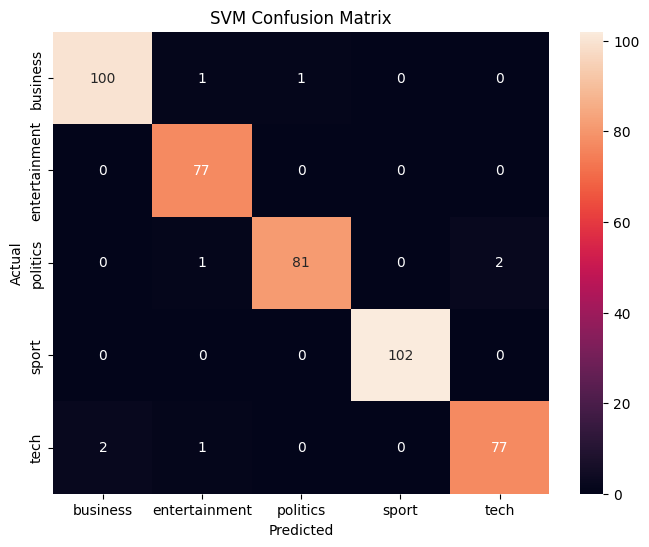

In [56]:
cm = confusion_matrix(
    y_test,
    svm_prediction
)


plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_
)


plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(
    "SVM Confusion Matrix"
)

plt.show()

# Part 16: Model Comparison

This compares accuracy between:
- Naive Bayes
- SVM

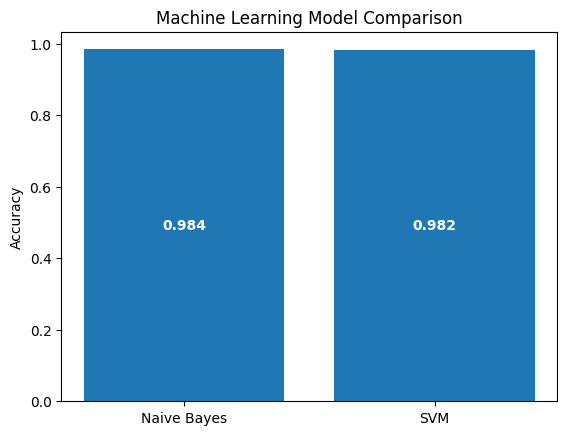

In [57]:
results = {

"Naive Bayes":
accuracy_score(
    y_test,
    nb_prediction
),


"SVM":
accuracy_score(
    y_test,
    svm_prediction
)

}


plt.bar(
    results.keys(),
    results.values()
)

# Add accuracy values to the middle of each bar
for i, (model_name, accuracy_value) in enumerate(results.items()):
    plt.text(i, accuracy_value / 2, f'{accuracy_value:.3f}', ha='center', va='center', color='white', fontweight='bold')

plt.ylabel(
"Accuracy"
)

plt.title(
"Machine Learning Model Comparison"
)

plt.show()

# Part 18: Save Trained Model

The trained SVM model and TF-IDF vectorizer
are saved for deployment in Streamlit.

In [58]:
import os

# Create the 'models' directory if it doesn't exist
os.makedirs('models', exist_ok=True)

joblib.dump(
    svm_model,
    "models/svm_model.pkl"
)


joblib.dump(
    tfidf_ngram,
    "models/tfidf_ngram.pkl"
)

['models/tfidf_ngram.pkl']

# Part 19: Test News Category Prediction

This section tests the trained NLP classification model
using a new unseen news article.

The input article will go through:

1. Text preprocessing
2. TF-IDF + N-gram feature transformation
3. SVM classification
4. Category prediction

The model will classify the article into:

- Business
- Entertainment
- Politics
- Sport
- Technology

In [59]:
# ============================================================
# Part 19: Test News Category Prediction
# BBC News Article Categorizer
# TF-IDF + N-gram + SVM Model
# ============================================================


# Import required library

import joblib



# ------------------------------------------------------------
# Step 1: Load Trained Model and TF-IDF Vectorizer
# ------------------------------------------------------------

svm_model = joblib.load(
    "models/svm_model.pkl"
)


tfidf_ngram = joblib.load(
    "models/tfidf.pkl"
)


print("Model and vectorizer loaded successfully!")



# ------------------------------------------------------------
# Step 2: Create New Unseen News Article
# ------------------------------------------------------------

new_article = """

Apple has announced a new artificial intelligence
technology system that will improve smartphone
performance and user experience.

"""



# ------------------------------------------------------------
# Step 3: Apply Text Preprocessing
# ------------------------------------------------------------

clean_article = preprocess_text(
    new_article
)



print("\nCleaned Article:")
print(clean_article)



# ------------------------------------------------------------
# Step 4: Convert Text into TF-IDF + N-gram Features
# ------------------------------------------------------------

article_vector = tfidf_ngram.transform(

    [clean_article]

)



# ------------------------------------------------------------
# Step 5: Predict News Category
# ------------------------------------------------------------

prediction = svm_model.predict(

    article_vector

)



# ------------------------------------------------------------
# Step 6: Display Prediction Result
# ------------------------------------------------------------

print("\n===================================")
print(" BBC NEWS CATEGORY PREDICTION ")
print("===================================")


print("\nOriginal Article:")
print(new_article)


print("\nPredicted Category:")

print(
    prediction[0].upper()
)

print("\n===================================")

Model and vectorizer loaded successfully!

Cleaned Article:
apple announced new artificial intelligence technology system improve smartphone performance user experience

 BBC NEWS CATEGORY PREDICTION 

Original Article:


Apple has announced a new artificial intelligence
technology system that will improve smartphone
performance and user experience.



Predicted Category:
TECH



In [60]:
from google.colab import files


files.download(
    "models/svm_model.pkl"
)


files.download(
    "models/tfidf.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>